In [185]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import json
from sklearn.ensemble import RandomForestClassifier

In [186]:
data = pd.read_csv("data/processed.csv")

In [187]:
data.describe()

,Unnamed: 0,attendance,FTHG,FTAG,PSH,PSD,PSA,MaxH,MaxD,MaxA,...,avg_fouls_per_match,home_rest_days,away_rest_days,home_points_last_5,away_points_last_5,h2h_home_win_pct,is_derby,diff_absences,home_momentum,away_momentum
count,718.000000,717.000000,718.000000,718.000000,590.000000,590.000000,590.000000,718.000000,718.000000,718.000000,...,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000
mean,358.500000,40940.132497,1.505571,1.334262,2.765797,4.329068,4.319593,2.849053,4.388120,4.529638,...,21.579387,11.137883,10.781337,6.753482,6.981894,0.372725,0.051532,-0.008357,-0.051630,-0.006630
std,207.413034,16749.304085,1.231546,1.152147,1.700834,1.275659,3.300084,1.914191,1.272759,3.812172,...,0.999839,36.297764,26.631968,3.440948,3.451348,0.271838,0.221234,2.580354,1.428796,1.561219
min,0.000000,10762.000000,0.000000,0.000000,1.080000,3.070000,1.190000,1.100000,3.150000,1.200000,...,19.600000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,-11.000000,-5.500000,-5.970000
25%,179.250000,29587.000000,1.000000,0.000000,1.650000,3.590000,2.260000,1.680000,3.692500,2.292500,...,20.800000,6.000000,5.000000,4.000000,4.000000,0.200000,0.000000,0.000000,-0.062500,0.000000
50%,358.500000,39316.000000,1.000000,1.000000,2.270000,3.910000,3.260000,2.280000,4.000000,3.345000,...,21.700000,7.000000,7.000000,7.000000,7.000000,0.400000,0.000000,0.000000,0.000000,0.000000
75%,537.750000,55527.000000,2.000000,2.000000,3.252500,4.575000,5.235000,3.250000,4.600000,5.400000,...,22.290000,8.000000,8.000000,9.000000,9.000000,0.600000,0.000000,0.000000,0.000000,0.000000
max,717.000000,74257.000000,7.000000,6.000000,14.010000,13.840000,25.710000,20.000000,14.000000,34.000000,...,24.690000,813.000000,454.000000,15.000000,15.000000,1.000000,1.000000,11.000000,5.980000,6.500000


In [188]:
data = data.drop(columns=['Unnamed: 0'])

In [189]:
data.head()

,date,home_team,away_team,attendance,FTHG,FTAG,PSH,PSD,PSA,MaxH,...,avg_fouls_per_match,home_rest_days,away_rest_days,home_points_last_5,away_points_last_5,h2h_home_win_pct,is_derby,diff_absences,home_momentum,away_momentum
0,2024-08-16,Manchester United,Fulham,73297.0,1,0,1.63,4.38,5.30,1.68,...,21.1,89.0,89.0,7.0,5.0,0.6,0,2,0.0,0.0
1,2024-08-17,Ipswich Town,Liverpool,30014.0,0,2,8.18,5.84,1.34,9.00,...,22.3,7.0,90.0,0.0,8.0,0.5,0,0,0.0,0.0
2,2024-08-17,Nottingham Forest,Bournemouth,29763.0,1,1,2.47,3.42,2.97,2.51,...,22.0,90.0,90.0,6.0,6.0,0.0,0,0,0.0,0.0
3,2024-08-17,Arsenal,Wolverhampton,60261.0,2,0,1.16,8.56,16.22,1.20,...,19.9,90.0,90.0,15.0,3.0,1.0,0,0,0.0,0.0
4,2024-08-17,Everton,Brighton & Hove Albion,39217.0,0,3,2.73,3.36,2.71,2.76,...,23.0,90.0,90.0,10.0,4.0,0.2,0,0,0.0,0.0


In [190]:
# Calculer le nombre de valeurs manquantes par colonne
missing_stats = data.isnull().sum()

# Ne garder que les colonnes qui ont au moins une valeur manquante
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)

print("--- Attributs avec des données manquantes ---")
print(missing_stats)

--- Attributs avec des données manquantes ---
CLCH          484
CLCA          484
CLCD          484
LBCH          479
LBCA          479
LBCD          479
CLD           473
CLH           473
LBD           473
LBA           473
CLA           473
LBH           473
BVCD          385
BVCA          385
BVCH          385
BVD           380
BVA           380
BVH           380
BMGMCA        380
BMGMCD        380
BMGMD         380
BMGMCH        380
BMGMA         380
BMGMH         380
P<2.5         131
P>2.5         131
PC<2.5        131
PC>2.5        131
PAHA          128
PSCH          128
PSD           128
PSA           128
PSH           128
PAHH          128
PSCD          128
PSCA          128
PCAHA         128
PCAHH         128
home_elo        7
away_elo        5
AHh             1
attendance      1
dtype: int64


In [191]:
# Supprimer les colonnes qui ont plus de 100 valeurs manquantes (c'est trop de bruit)
# Cela va supprimer automatiquement toutes les colonnes de cotes incomplètes
data = data.dropna(thresh=len(data) - 100, axis=1)

print(f"Colonnes restantes après nettoyage des cotes : {len(data.columns)}")

Colonnes restantes après nettoyage des cotes : 103


In [192]:
# Calculer le nombre de valeurs manquantes par colonne
missing_stats = data.isnull().sum()

# Ne garder que les colonnes qui ont au moins une valeur manquante
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)

print("--- Attributs avec des données manquantes ---")
print(missing_stats)

--- Attributs avec des données manquantes ---
home_elo      7
away_elo      5
AHh           1
attendance    1
dtype: int64


In [193]:
data['AHh'] = data['AHh'].fillna(0)

In [194]:
# Calculer le nombre de valeurs manquantes par colonne
missing_stats = data.isnull().sum()

# Ne garder que les colonnes qui ont au moins une valeur manquante
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)

print("--- Attributs avec des données manquantes ---")
print(missing_stats)

--- Attributs avec des données manquantes ---
home_elo      7
away_elo      5
attendance    1
dtype: int64


In [195]:
data.iloc[-6]

date                       2026-04-24
home_team                  Sunderland
away_team           Nottingham Forest
attendance                        NaN
FTHG                                0
                          ...        
h2h_home_win_pct                  1.0
is_derby                            0
diff_absences                       0
home_momentum                   -0.92
away_momentum                    4.22
Name: 712, Length: 103, dtype: object

In [196]:
data.loc[(data['home_team'] == "Sunderland") & (data['date'] == "2026-04-24"), 'attendance'] = 47047

In [197]:
data.iloc[-6]

date                       2026-04-24
home_team                  Sunderland
away_team           Nottingham Forest
attendance                    47047.0
FTHG                                0
                          ...        
h2h_home_win_pct                  1.0
is_derby                            0
diff_absences                       0
home_momentum                   -0.92
away_momentum                    4.22
Name: 712, Length: 103, dtype: object

In [198]:
# Calculer le nombre de valeurs manquantes par colonne
missing_stats = data.isnull().sum()

# Ne garder que les colonnes qui ont au moins une valeur manquante
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)

print("--- Attributs avec des données manquantes ---")
print(missing_stats)

--- Attributs avec des données manquantes ---
home_elo    7
away_elo    5
dtype: int64


In [199]:
# 1. Trier par date pour garantir l'ordre chronologique
data = data.sort_values(by='date').reset_index(drop=True)

# 2. Imputation par "backfill" (bfill)
# Cela remplace la valeur manquante par la première valeur valide trouvée en dessous
data['home_elo'] = data['home_elo'].bfill()
data['away_elo'] = data['away_elo'].bfill()

In [200]:
# Calculer le nombre de valeurs manquantes par colonne
missing_stats = data.isnull().sum()

# Ne garder que les colonnes qui ont au moins une valeur manquante
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)

print("--- Attributs avec des données manquantes ---")
print(missing_stats)

--- Attributs avec des données manquantes ---
Series([], dtype: int64)


In [201]:
import pandas as pd
import numpy as np

def calculate_pi_ratings(df, learning_rate=0.1, scale_factor=0.05, home_advantage=0.3):
    """
    Calcule un Pi-Rating simplifié (basé sur la différence de buts attendue vs réelle).
    
    Paramètres:
    - learning_rate (lambda) : Vitesse à laquelle le rating s'ajuste après un match.
    - scale_factor (c) : Facteur d'échelle pour convertir l'écart de rating en buts attendus.
    - home_advantage (gamma) : Avantage moyen à domicile (en termes de différence de buts).
    """
    # Dictionnaire pour stocker le rating dynamique de chaque équipe (commence à 0)
    ratings = {}
    
    # Listes pour stocker les ratings AVANT le match (c'est ça qu'on donne au modèle)
    home_pi_history = []
    away_pi_history = []
    
    # On itère chronologiquement sur les matchs
    for index, row in df.iterrows():
        home = row['home_team']
        away = row['away_team']
        hg = row['FTHG'] # Home Goals
        ag = row['FTAG'] # Away Goals
        
        # Initialisation des équipes si c'est leur premier match dans la base
        if home not in ratings: ratings[home] = 0.0
        if away not in ratings: ratings[away] = 0.0
            
        # 1. Sauvegarder les ratings pré-match pour le DataFrame
        r_home = ratings[home]
        r_away = ratings[away]
        
        home_pi_history.append(r_home)
        away_pi_history.append(r_away)
        
        # --- CALCUL DE MISE À JOUR (POST-MATCH) ---
        
        # Différence de buts réelle
        actual_gd = hg - ag
        
        # Différence de buts attendue (Expected Goal Difference)
        # Plus l'écart de rating est grand, plus on attend de buts d'écart
        expected_gd = (r_home - r_away) * scale_factor + home_advantage
        
        # Erreur de prédiction (différence entre la réalité et nos attentes)
        error = actual_gd - expected_gd
        
        # Mise à jour des ratings pour le prochain match
        # Si l'équipe a fait mieux que prévu (error > 0), son rating monte.
        ratings[home] = r_home + (learning_rate * error)
        ratings[away] = r_away - (learning_rate * error)
        
    # Ajouter les colonnes au DataFrame
    df['home_pi_rating'] = home_pi_history
    df['away_pi_rating'] = away_pi_history
    return df

data = data.sort_values('date').reset_index(drop=True)
data = calculate_pi_ratings(data)

In [202]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Columns: 105 entries, date to away_pi_rating
dtypes: float64(92), int64(4), str(9)
memory usage: 636.8 KB


In [203]:
ordre_ligne = {"low": 1, "mid": 2, "high": 3}

# On applique cet ordre sur les colonnes correspondantes
data["home_manager_defensive_line"] = data["home_manager_defensive_line"].map(ordre_ligne)
data["away_manager_defensive_line"] = data["away_manager_defensive_line"].map(ordre_ligne)


# --- 2. ONE-HOT ENCODING (Pour les catégories sans ordre) ---
# On liste les variables nominales (Formations et Styles)
colonnes_nominales = [
    "home_manager_preferred_formation", 
    "away_manager_preferred_formation",
    "home_manager_team_style", 
    "away_manager_team_style"
]

# On transforme uniquement ces colonnes en nouvelles variables binaires (0 ou 1)
data = pd.get_dummies(data, columns=colonnes_nominales)
data.head()

,date,home_team,away_team,attendance,FTHG,FTAG,MaxH,MaxD,MaxA,AvgH,...,home_manager_preferred_formation_4-3-3,away_manager_preferred_formation_3-4-2-1,away_manager_preferred_formation_3-5-2,away_manager_preferred_formation_4-1-4-1,away_manager_preferred_formation_4-2-3-1,away_manager_preferred_formation_4-3-3,home_manager_team_style_neutral,home_manager_team_style_soft,away_manager_team_style_neutral,away_manager_team_style_soft
0,2024-08-16,Manchester United,Fulham,73297.0,1,0,1.68,4.50,5.50,1.62,...,False,False,False,False,True,False,True,False,True,False
1,2024-08-17,Ipswich Town,Liverpool,30014.0,0,2,9.00,6.10,1.37,8.28,...,False,False,False,False,True,False,True,False,False,True
2,2024-08-17,Nottingham Forest,Bournemouth,29763.0,1,1,2.51,3.70,3.00,2.45,...,False,False,False,False,True,False,True,False,True,False
3,2024-08-17,Arsenal,Wolverhampton,60261.0,2,0,1.20,9.10,18.00,1.18,...,True,False,True,False,False,False,False,True,True,False
4,2024-08-17,Everton,Brighton & Hove Albion,39217.0,0,3,2.76,3.66,2.78,2.67,...,False,False,False,False,True,False,True,False,True,False


In [204]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Columns: 115 entries, date to away_manager_team_style_soft
dtypes: bool(14), float64(92), int64(6), str(3)
memory usage: 600.8 KB


In [205]:
data_features = data.drop(columns=["home_team", "away_team", "date", "FTHG", "FTAG"])
data_features.head()

,attendance,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,Max>2.5,Max<2.5,Avg>2.5,...,home_manager_preferred_formation_4-3-3,away_manager_preferred_formation_3-4-2-1,away_manager_preferred_formation_3-5-2,away_manager_preferred_formation_4-1-4-1,away_manager_preferred_formation_4-2-3-1,away_manager_preferred_formation_4-3-3,home_manager_team_style_neutral,home_manager_team_style_soft,away_manager_team_style_neutral,away_manager_team_style_soft
0,73297.0,1.68,4.50,5.50,1.62,4.36,5.15,1.57,2.60,1.53,...,False,False,False,False,True,False,True,False,True,False
1,30014.0,9.00,6.10,1.37,8.28,5.76,1.34,1.43,3.07,1.41,...,False,False,False,False,True,False,True,False,False,True
2,29763.0,2.51,3.70,3.00,2.45,3.49,2.89,1.81,2.14,1.77,...,False,False,False,False,True,False,True,False,True,False
3,60261.0,1.20,9.10,18.00,1.18,7.86,15.87,1.50,2.82,1.46,...,True,False,True,False,False,False,False,True,True,False
4,39217.0,2.76,3.66,2.78,2.67,3.41,2.68,1.85,2.08,1.81,...,False,False,False,False,True,False,True,False,True,False


In [206]:
data_bonus = data[["home_team", "away_team", "date", "FTHG", "FTAG"]]
data_bonus.head()

,home_team,away_team,date,FTHG,FTAG
0,Manchester United,Fulham,2024-08-16,1,0
1,Ipswich Town,Liverpool,2024-08-17,0,2
2,Nottingham Forest,Bournemouth,2024-08-17,1,1
3,Arsenal,Wolverhampton,2024-08-17,2,0
4,Everton,Brighton & Hove Albion,2024-08-17,0,3


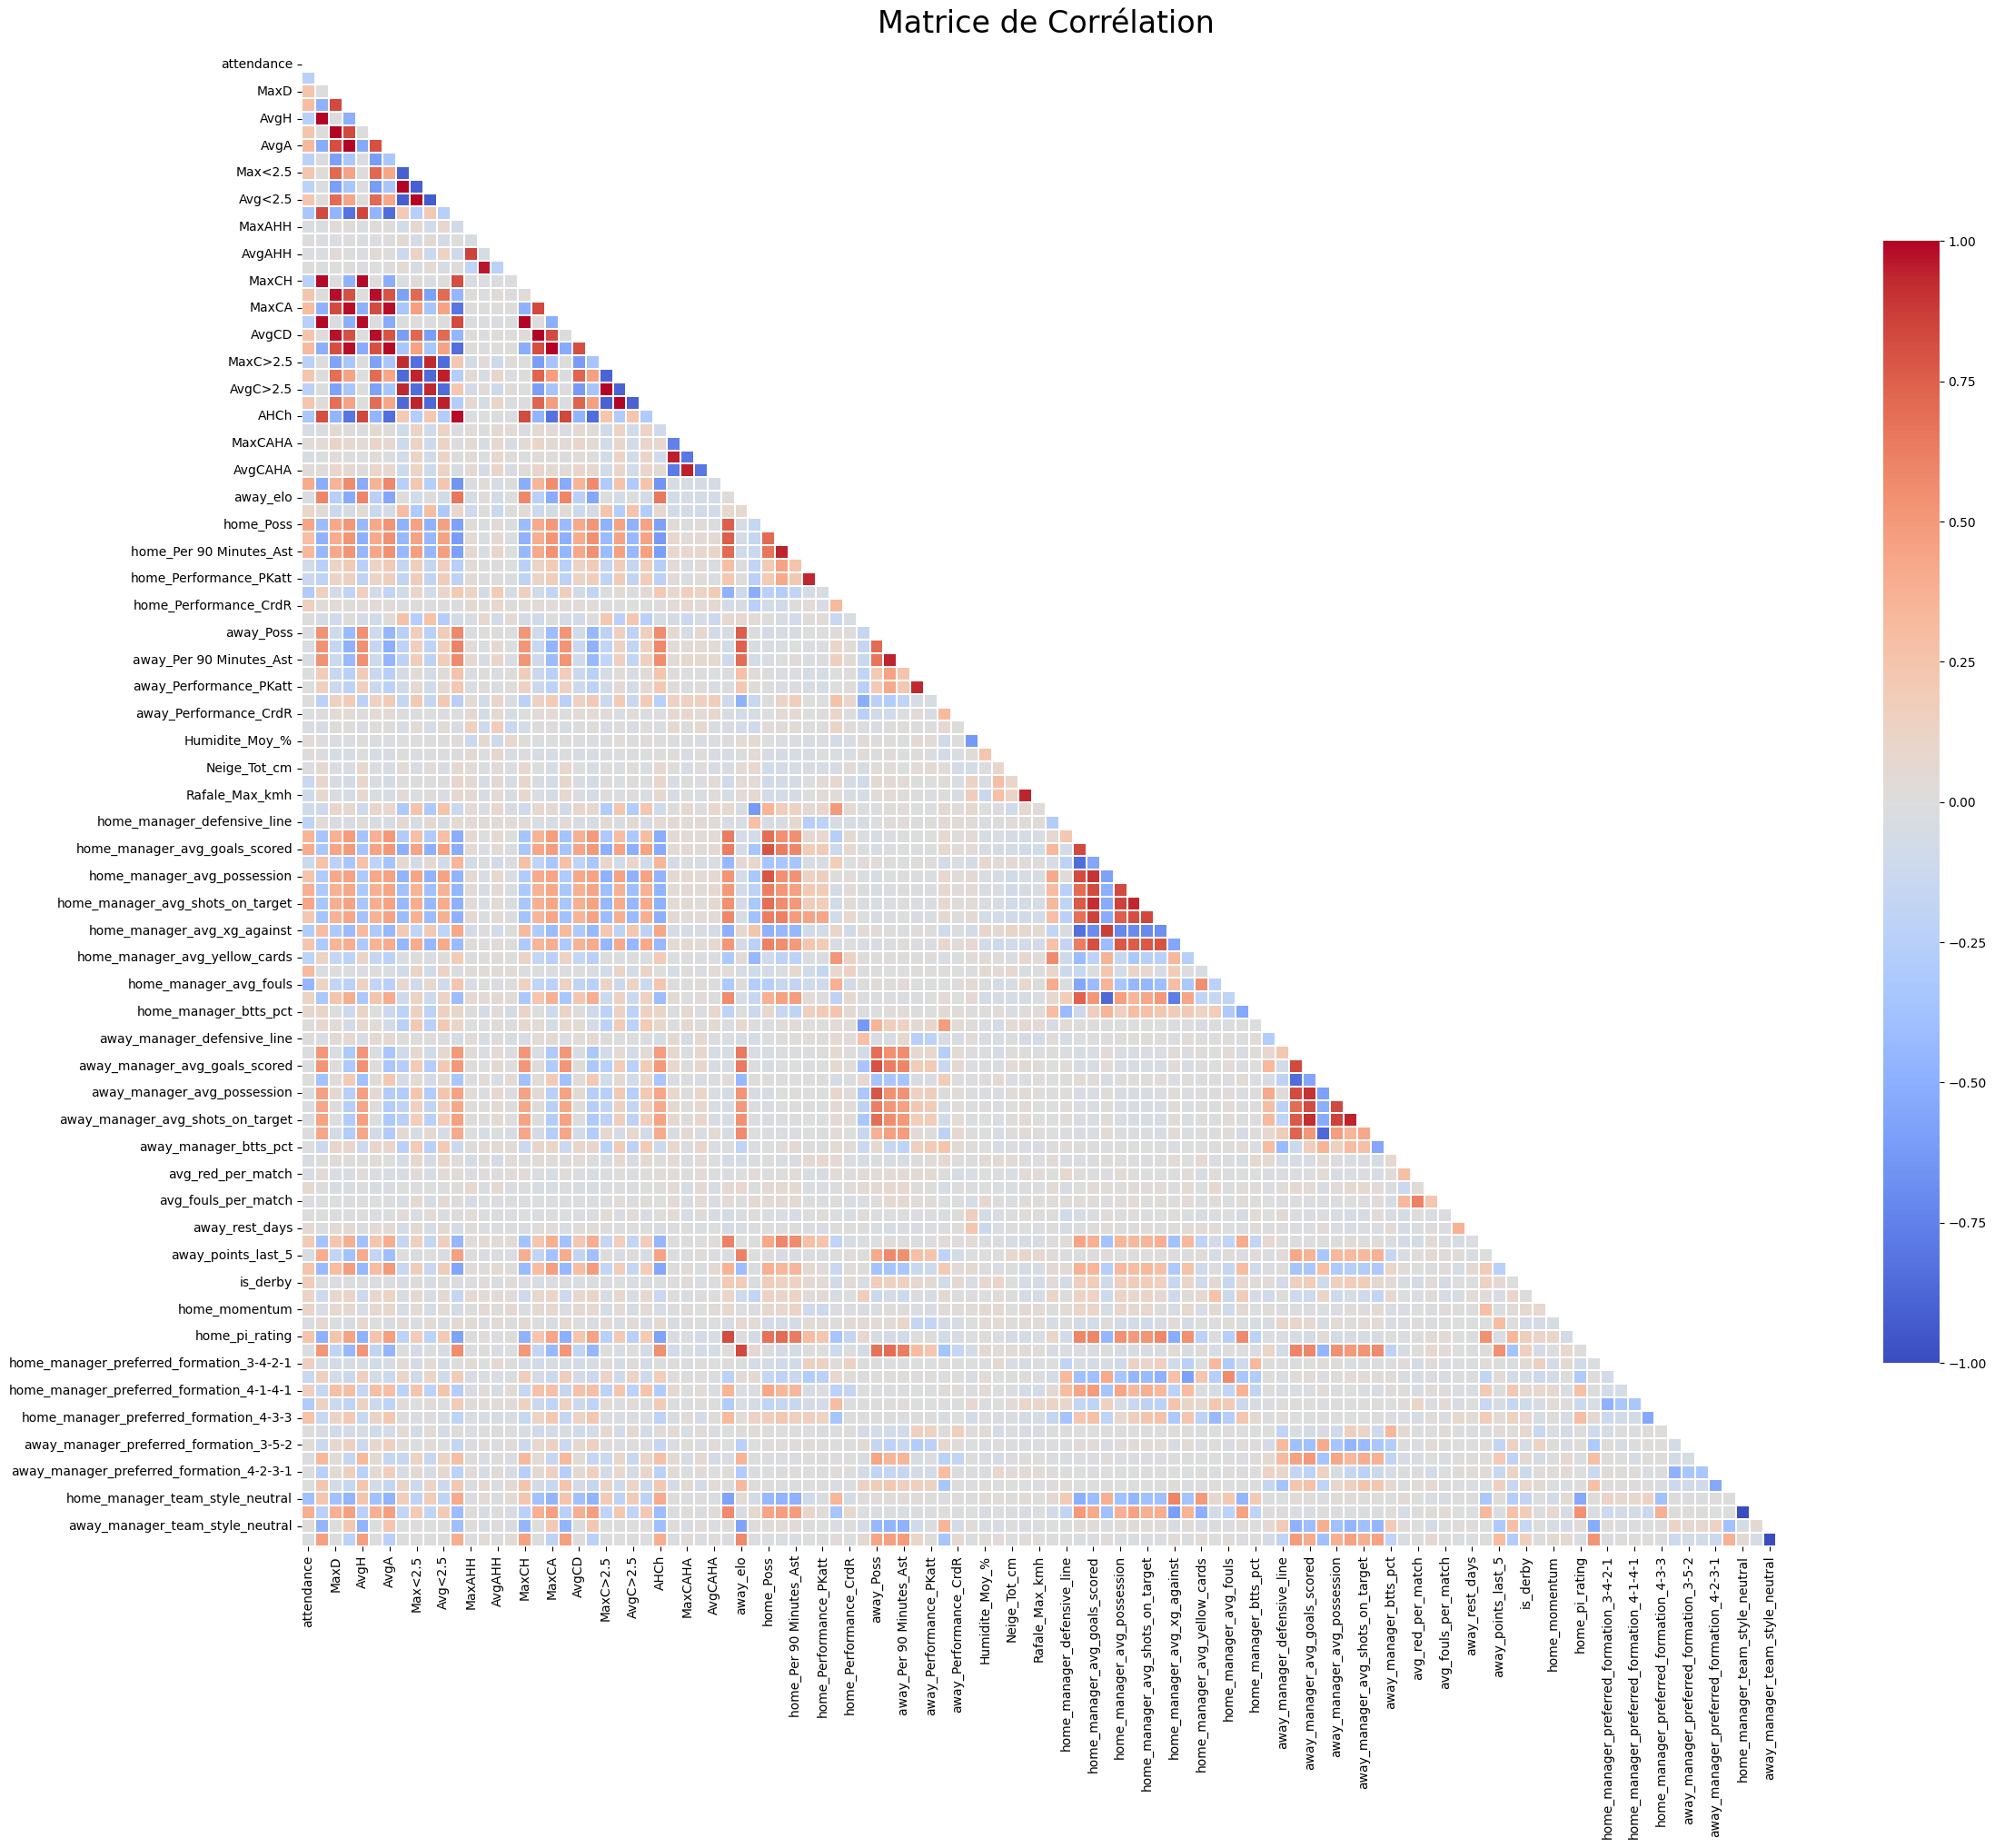

In [207]:
corr_matrix = data_features.corr()

# 2. Création d'un masque pour cacher le triangle supérieur 
# (La matrice est symétrique, afficher les deux moitiés alourdit la lecture)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Configuration de la figure (très grande taille nécessaire pour 104 variables)
plt.figure(figsize=(24, 20))

# 4. Affichage de la Heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm',          # Bleu pour corrélation négative, Rouge pour positive
    vmax=1.0, vmin=-1.0,      # L'échelle va strictement de -1 à 1
    center=0, 
    square=True, 
    linewidths=0.1,           # Fines lignes de séparation
    cbar_kws={"shrink": .75}, # Ajustement de la barre de légende
    annot=False
)

plt.title("Matrice de Corrélation", fontsize=24, pad=20)
plt.tight_layout()
plt.show()

In [208]:
# 1. On définit ton seuil de tolérance 
# (0.80 est un bon standard, 0.90 est plus conservateur)
SEUIL_CORRELATION = 0.80

# 3. On crée un masque pour ne regarder que la moitié supérieure de la matrice
# (Pour éviter d'avoir "A corrélé avec B" puis "B corrélé avec A", et "A corrélé avec A")
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. On cherche les paires qui dépassent le seuil (en positif OU en négatif)
colonnes_a_supprimer = []
paires_trouvees = []

for colonne in upper_triangle.columns:
    for index in upper_triangle.index:
        valeur_corr = upper_triangle.loc[index, colonne]
        
        # Si la corrélation absolue (sans le signe -) est supérieure au seuil
        if abs(valeur_corr) > SEUIL_CORRELATION:
            paires_trouvees.append((index, colonne, valeur_corr))
            # On ajoute la colonne à la liste des suppressions potentielles
            colonnes_a_supprimer.append(colonne)

# 5. Affichage des résultats
print(f"--- PAIRES HAUTEMENT CORRÉLÉES (> {SEUIL_CORRELATION}) ---")
if not paires_trouvees:
    print("Aucune paire ne dépasse ce seuil. Tes données sont peu redondantes !")
else:
    for paire in paires_trouvees:
        print(f"🔹 {paire[0]} <---> {paire[1]} : {paire[2]:.2f}")

# 6. Liste des colonnes suggérées pour la suppression
colonnes_a_supprimer = list(set(colonnes_a_supprimer)) # Pour enlever les doublons

--- PAIRES HAUTEMENT CORRÉLÉES (> 0.8) ---
🔹 MaxD <---> MaxA : 0.83
🔹 MaxH <---> AvgH : 1.00
🔹 MaxD <---> AvgD : 1.00
🔹 MaxA <---> AvgD : 0.83
🔹 MaxD <---> AvgA : 0.81
🔹 MaxA <---> AvgA : 1.00
🔹 AvgD <---> AvgA : 0.81
🔹 Max>2.5 <---> Max<2.5 : -0.91
🔹 Max>2.5 <---> Avg>2.5 : 1.00
🔹 Max<2.5 <---> Avg>2.5 : -0.91
🔹 Max>2.5 <---> Avg<2.5 : -0.92
🔹 Max<2.5 <---> Avg<2.5 : 0.99
🔹 Avg>2.5 <---> Avg<2.5 : -0.92
🔹 MaxH <---> AHh : 0.83
🔹 MaxA <---> AHh : -0.82
🔹 AvgH <---> AHh : 0.85
🔹 AvgA <---> AHh : -0.85
🔹 MaxAHH <---> AvgAHH : 0.85
🔹 MaxAHA <---> AvgAHA : 0.96
🔹 MaxH <---> MaxCH : 0.99
🔹 AvgH <---> MaxCH : 0.98
🔹 AHh <---> MaxCH : 0.82
🔹 MaxD <---> MaxCD : 0.98
🔹 MaxA <---> MaxCD : 0.81
🔹 AvgD <---> MaxCD : 0.98
🔹 MaxD <---> MaxCA : 0.82
🔹 MaxA <---> MaxCA : 0.98
🔹 AvgD <---> MaxCA : 0.82
🔹 AvgA <---> MaxCA : 0.98
🔹 AHh <---> MaxCA : -0.81
🔹 MaxCD <---> MaxCA : 0.83
🔹 MaxH <---> AvgCH : 0.99
🔹 AvgH <---> AvgCH : 0.99
🔹 AHh <---> AvgCH : 0.83
🔹 MaxCH <---> AvgCH : 1.00
🔹 MaxD <---> AvgCD :

In [210]:
# 1. Liste exhaustive des colonnes à supprimer suite à notre analyse
colonnes_a_jeter = [
    "home_elo", "away_elo",
    # --- 1. Piège des variables muettes (Colinéarité parfaite) ---
    "home_manager_team_style_soft",
    "away_manager_team_style_soft",
    
    # --- 2. Cotes Bookmakers (On ne garde que les moyennes de fermeture : AvgCH, AvgCD, AvgCA, AvgC>2.5 et AvgCAHH) ---
    "MaxH", "MaxD", "MaxA", 
    "AvgH", "AvgD", "AvgA", 
    "MaxCH", "MaxCD", "MaxCA",
    "Max>2.5", "Max<2.5", "Avg>2.5", "Avg<2.5", 
    "MaxC>2.5", "MaxC<2.5", "AvgC<2.5", # On garde uniquement AvgC>2.5 pour l'Over/Under
    "AHh", "AHCh", "MaxAHH", "MaxAHA", "AvgAHA", 
    "MaxCAHH", "MaxCAHA", "AvgCAHA",    # On garde uniquement AvgCAHH pour l'Asian Handicap
    
    # --- 3. Redondances Physiques et Statistiques d'équipe ---
    "Rafale_Max_kmh",             # On garde Vent_Moy_kmh
    "home_Performance_PK",        # On garde les penaltys tentés (PKatt)
    "away_Performance_PK",
    "home_Per 90 Minutes_Ast",    # On garde les buts (Gls)
    "away_Per 90 Minutes_Ast",
    
    # --- 4. Redondances Managers (On garde win_pct, xg_for, xg_against) ---
    "home_manager_avg_goals_scored",
    "home_manager_avg_goals_conceded",
    "home_manager_avg_possession",
    "home_manager_avg_shots",
    "home_manager_avg_shots_on_target",
    
    "away_manager_avg_goals_scored",
    "away_manager_avg_goals_conceded",
    "away_manager_avg_possession",
    "away_manager_avg_shots",
    "away_manager_avg_shots_on_target"
]
data_features = data_features.drop(columns=colonnes_a_jeter)
data.shape

(718, 115)

In [211]:
corr_matrix = data_features.corr()

# 3. On crée un masque pour ne regarder que la moitié supérieure de la matrice
# (Pour éviter d'avoir "A corrélé avec B" puis "B corrélé avec A", et "A corrélé avec A")
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. On cherche les paires qui dépassent le seuil (en positif OU en négatif)
colonnes_a_supprimer = []
paires_trouvees = []

for colonne in upper_triangle.columns:
    for index in upper_triangle.index:
        valeur_corr = upper_triangle.loc[index, colonne]
        
        # Si la corrélation absolue (sans le signe -) est supérieure au seuil
        if abs(valeur_corr) > SEUIL_CORRELATION:
            paires_trouvees.append((index, colonne, valeur_corr))
            # On ajoute la colonne à la liste des suppressions potentielles
            colonnes_a_supprimer.append(colonne)

# 5. Affichage des résultats
print(f"--- PAIRES HAUTEMENT CORRÉLÉES (> {SEUIL_CORRELATION}) ---")
if not paires_trouvees:
    print("Aucune paire ne dépasse ce seuil. Tes données sont peu redondantes !")
else:
    for paire in paires_trouvees:
        print(f"🔹 {paire[0]} <---> {paire[1]} : {paire[2]:.2f}")

# 6. Liste des colonnes suggérées pour la suppression
colonnes_a_supprimer = list(set(colonnes_a_supprimer)) # Pour enlever les doublons

--- PAIRES HAUTEMENT CORRÉLÉES (> 0.8) ---
🔹 AvgCD <---> AvgCA : 0.81
🔹 home_manager_win_pct <---> home_manager_avg_xg_against : -0.83


In [212]:
data.head()

,date,home_team,away_team,attendance,FTHG,FTAG,MaxH,MaxD,MaxA,AvgH,...,home_manager_preferred_formation_4-3-3,away_manager_preferred_formation_3-4-2-1,away_manager_preferred_formation_3-5-2,away_manager_preferred_formation_4-1-4-1,away_manager_preferred_formation_4-2-3-1,away_manager_preferred_formation_4-3-3,home_manager_team_style_neutral,home_manager_team_style_soft,away_manager_team_style_neutral,away_manager_team_style_soft
0,2024-08-16,Manchester United,Fulham,73297.0,1,0,1.68,4.50,5.50,1.62,...,False,False,False,False,True,False,True,False,True,False
1,2024-08-17,Ipswich Town,Liverpool,30014.0,0,2,9.00,6.10,1.37,8.28,...,False,False,False,False,True,False,True,False,False,True
2,2024-08-17,Nottingham Forest,Bournemouth,29763.0,1,1,2.51,3.70,3.00,2.45,...,False,False,False,False,True,False,True,False,True,False
3,2024-08-17,Arsenal,Wolverhampton,60261.0,2,0,1.20,9.10,18.00,1.18,...,True,False,True,False,False,False,False,True,True,False
4,2024-08-17,Everton,Brighton & Hove Albion,39217.0,0,3,2.76,3.66,2.78,2.67,...,False,False,False,False,True,False,True,False,True,False


In [213]:
data_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 67 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   attendance                                718 non-null    float64
 1   AvgAHH                                    718 non-null    float64
 2   AvgCH                                     718 non-null    float64
 3   AvgCD                                     718 non-null    float64
 4   AvgCA                                     718 non-null    float64
 5   AvgC>2.5                                  718 non-null    float64
 6   AvgCAHH                                   718 non-null    float64
 7   home_Age                                  718 non-null    float64
 8   home_Poss                                 718 non-null    float64
 9   home_Per 90 Minutes_Gls                   718 non-null    float64
 10  home_Performance_PKatt                    718 non

In [214]:
data_features.shape

(718, 67)

In [215]:
data_features = data_features.astype(float)

In [216]:
# 1. Préparation (ajout de la constante obligatoire)
X = add_constant(data_features)

# 2. Calcul du VIF
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 3. Affichage du Top 5 des pires variables (hors constante)
vif_df = vif_df[vif_df["Variable"] != "const"]
print(vif_df.sort_values("VIF", ascending=False).head(50))

C:\Users\MUEL\Desktop\INSA\IF\4A\INSA\SMART\QSport\venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


                                    Variable        VIF
57    home_manager_preferred_formation_3-5-2        inf
65    away_manager_preferred_formation_4-3-3        inf
64  away_manager_preferred_formation_4-2-3-1        inf
61  away_manager_preferred_formation_3-4-2-1        inf
60    home_manager_preferred_formation_4-3-3        inf
59  home_manager_preferred_formation_4-2-3-1        inf
56  home_manager_preferred_formation_3-4-2-1        inf
63  away_manager_preferred_formation_4-1-4-1        inf
62    away_manager_preferred_formation_3-5-2        inf
58  home_manager_preferred_formation_4-1-4-1        inf
5                                      AvgCA  66.516830
4                                      AvgCD  62.123539
27                      home_manager_win_pct  49.281431
35                     home_manager_btts_pct  45.867655
34              home_manager_clean_sheet_pct  36.971888
33                    home_manager_avg_fouls  35.773473
25           home_manager_pressing_intensity  30

C:\Users\MUEL\Desktop\INSA\IF\4A\INSA\SMART\QSport\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [217]:
# 1. On casse le piège de l'infini en supprimant une formation de référence
colonnes_reference = [
    'home_manager_preferred_formation_3-5-2',
    'away_manager_preferred_formation_3-5-2'
]
data_features = data_features.drop(columns=colonnes_reference)

In [218]:
# 2. On recalcule le VIF
X = add_constant(data_features)

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_df = vif_df[vif_df["Variable"] != "const"]
print(vif_df.sort_values("VIF", ascending=False).head(20))

                                    Variable        VIF
5                                      AvgCA  66.516830
4                                      AvgCD  62.123539
59    home_manager_preferred_formation_4-3-3  54.876995
58  home_manager_preferred_formation_4-2-3-1  51.874171
27                      home_manager_win_pct  49.281431
35                     home_manager_btts_pct  45.867655
56  home_manager_preferred_formation_3-4-2-1  44.947345
63    away_manager_preferred_formation_4-3-3  39.169500
34              home_manager_clean_sheet_pct  36.971888
62  away_manager_preferred_formation_4-2-3-1  36.296110
33                    home_manager_avg_fouls  35.773473
25           home_manager_pressing_intensity  30.654787
60  away_manager_preferred_formation_3-4-2-1  26.398578
29               home_manager_avg_xg_against  23.219029
30                  home_manager_avg_corners  22.331295
3                                      AvgCH  22.045733
39              away_manager_clean_sheet_pct  20

In [219]:
data_features = data_features.drop(columns=["AvgCD"])

In [220]:
# 2. On recalcule le VIF
X = add_constant(data_features)

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_df = vif_df[vif_df["Variable"] != "const"]
print(vif_df.sort_values("VIF", ascending=False).head(20))

                                    Variable        VIF
58    home_manager_preferred_formation_4-3-3  53.050497
57  home_manager_preferred_formation_4-2-3-1  50.755011
26                      home_manager_win_pct  49.093620
34                     home_manager_btts_pct  45.842800
55  home_manager_preferred_formation_3-4-2-1  43.642240
62    away_manager_preferred_formation_4-3-3  39.164687
33              home_manager_clean_sheet_pct  36.880227
61  away_manager_preferred_formation_4-2-3-1  36.288157
32                    home_manager_avg_fouls  35.445124
24           home_manager_pressing_intensity  30.641989
59  away_manager_preferred_formation_3-4-2-1  26.394878
28               home_manager_avg_xg_against  23.108409
29                  home_manager_avg_corners  22.326995
38              away_manager_clean_sheet_pct  20.307243
56  home_manager_preferred_formation_4-1-4-1  19.364909
60  away_manager_preferred_formation_4-1-4-1  13.647654
39                     away_manager_btts_pct  12

In [221]:
colonnes_reference = [
    'home_manager_preferred_formation_4-3-3',
    'away_manager_preferred_formation_4-3-3'
]
data_features = data_features.drop(columns=colonnes_reference)

In [222]:
# 2. On recalcule le VIF
X = add_constant(data_features)

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_df = vif_df[vif_df["Variable"] != "const"]
print(vif_df.sort_values("VIF", ascending=False).head(20))

                                    Variable        VIF
26                      home_manager_win_pct  44.908096
34                     home_manager_btts_pct  41.591343
24           home_manager_pressing_intensity  30.600527
32                    home_manager_avg_fouls  30.160422
33              home_manager_clean_sheet_pct  23.490088
29                  home_manager_avg_corners  22.293051
28               home_manager_avg_xg_against  21.394185
8                                  home_Poss  12.589311
31                home_manager_avg_red_cards  12.075496
27                   home_manager_avg_xg_for  11.839741
37                      away_manager_win_pct   9.458495
38              away_manager_clean_sheet_pct   8.646183
55  home_manager_preferred_formation_3-4-2-1   8.243670
30             home_manager_avg_yellow_cards   7.977529
14                                 away_Poss   6.982014
9                    home_Per 90 Minutes_Gls   5.913727
25               home_manager_defensive_line   5

In [223]:
data_features = data_features.drop(columns=["home_manager_win_pct"])

In [224]:
# 2. On recalcule le VIF
X = add_constant(data_features)

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_df = vif_df[vif_df["Variable"] != "const"]
print(vif_df.sort_values("VIF", ascending=False).head(20))

                                    Variable        VIF
33                     home_manager_btts_pct  41.281002
24           home_manager_pressing_intensity  26.527703
32              home_manager_clean_sheet_pct  22.667793
28                  home_manager_avg_corners  22.280314
31                    home_manager_avg_fouls  20.824715
27               home_manager_avg_xg_against  18.005923
26                   home_manager_avg_xg_for  11.825797
8                                  home_Poss  11.341985
36                      away_manager_win_pct   9.457954
37              away_manager_clean_sheet_pct   8.644701
30                home_manager_avg_red_cards   8.526203
54  home_manager_preferred_formation_3-4-2-1   8.215407
14                                 away_Poss   6.979952
9                    home_Per 90 Minutes_Gls   5.776221
29             home_manager_avg_yellow_cards   5.649345
60           home_manager_team_style_neutral   5.232548
15                   away_Per 90 Minutes_Gls   5

In [225]:
data_features = data_features.drop(columns=["home_manager_btts_pct"])

In [226]:
# 2. On recalcule le VIF
X = add_constant(data_features)

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_df = vif_df[vif_df["Variable"] != "const"]
print(vif_df.sort_values("VIF", ascending=False).head(20))

                                    Variable        VIF
27               home_manager_avg_xg_against  13.177784
26                   home_manager_avg_xg_for  11.482667
35                      away_manager_win_pct   9.447805
28                  home_manager_avg_corners   9.310228
36              away_manager_clean_sheet_pct   8.643936
8                                  home_Poss   8.085623
14                                 away_Poss   6.940937
24           home_manager_pressing_intensity   6.313131
32              home_manager_clean_sheet_pct   5.958647
30                home_manager_avg_red_cards   5.631606
9                    home_Per 90 Minutes_Gls   5.573473
29             home_manager_avg_yellow_cards   5.548646
53  home_manager_preferred_formation_3-4-2-1   5.500442
15                   away_Per 90 Minutes_Gls   5.103930
37                     away_manager_btts_pct   5.035663
3                                      AvgCH   4.782905
59           home_manager_team_style_neutral   4

In [227]:
data_features = data_features.drop(columns=["home_manager_avg_xg_against"])

In [228]:
# 2. On recalcule le VIF
X = add_constant(data_features)

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_df = vif_df[vif_df["Variable"] != "const"]
print(vif_df.sort_values("VIF", ascending=False).head(20))

                                    Variable        VIF
26                   home_manager_avg_xg_for  11.420050
34                      away_manager_win_pct   9.420318
35              away_manager_clean_sheet_pct   8.629380
27                  home_manager_avg_corners   8.326863
8                                  home_Poss   7.609242
14                                 away_Poss   6.923044
9                    home_Per 90 Minutes_Gls   5.537797
15                   away_Per 90 Minutes_Gls   5.103565
36                     away_manager_btts_pct   5.032048
24           home_manager_pressing_intensity   4.980635
3                                      AvgCH   4.759050
11                     home_Performance_CrdY   4.528745
50                            home_pi_rating   4.487715
52  home_manager_preferred_formation_3-4-2-1   4.261474
28             home_manager_avg_yellow_cards   4.242546
58           home_manager_team_style_neutral   4.172902
4                                      AvgCA   4

In [229]:
data_features = data_features.drop(columns=["home_manager_avg_xg_for"])

In [230]:
# 2. On recalcule le VIF
X = add_constant(data_features)

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_df = vif_df[vif_df["Variable"] != "const"]
print(vif_df.sort_values("VIF", ascending=False).head(20))

                           Variable       VIF
33             away_manager_win_pct  9.420132
34     away_manager_clean_sheet_pct  8.624209
8                         home_Poss  7.595584
14                        away_Poss  6.917186
9           home_Per 90 Minutes_Gls  5.506237
35            away_manager_btts_pct  5.031223
15          away_Per 90 Minutes_Gls  5.029654
24  home_manager_pressing_intensity  4.967633
3                             AvgCH  4.745801
11            home_Performance_CrdY  4.509703
49                   home_pi_rating  4.465360
26         home_manager_avg_corners  4.412475
4                             AvgCA  4.121399
57  home_manager_team_style_neutral  4.106727
50                   away_pi_rating  4.091694
30     home_manager_clean_sheet_pct  4.073380
27    home_manager_avg_yellow_cards  4.058582
17            away_Performance_CrdY  3.815872
31  away_manager_pressing_intensity  3.735743
28       home_manager_avg_red_cards  3.689484


In [231]:
data_features.shape

(718, 58)

In [232]:
data_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 58 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   attendance                                718 non-null    float64
 1   AvgAHH                                    718 non-null    float64
 2   AvgCH                                     718 non-null    float64
 3   AvgCA                                     718 non-null    float64
 4   AvgC>2.5                                  718 non-null    float64
 5   AvgCAHH                                   718 non-null    float64
 6   home_Age                                  718 non-null    float64
 7   home_Poss                                 718 non-null    float64
 8   home_Per 90 Minutes_Gls                   718 non-null    float64
 9   home_Performance_PKatt                    718 non-null    float64
 10  home_Performance_CrdY                     718 non

In [234]:
# 1. On crée une copie pour travailler proprement
data_engineered = data_features.copy()

# 2. Liste des métriques symétriques (qui ont survécu au VIF pour Home ET Away)
metriques_symetriques = [
    "pi_rating",
    "Age",
    "Poss",
    "Per 90 Minutes_Gls",
    "Performance_PKatt",
    "Performance_CrdY",
    "Performance_CrdR",
    "manager_pressing_intensity",
    "manager_defensive_line",
    "manager_clean_sheet_pct",
    "manager_team_style_neutral",
    "momentum"
]

# 3. Création des variables de différence (Différence positive = Avantage pour Domicile)
for metrique in metriques_symetriques:
    col_home = f"home_{metrique}"
    col_away = f"away_{metrique}"
    data_engineered[f"diff_{metrique}"] = data_engineered[col_home] - data_engineered[col_away]

# 4. Feature Engineering Spécial : L'avis du marché
data_engineered["diff_Cotes"] = data_engineered["AvgCA"] - data_engineered["AvgCH"]
data_engineered['diff_rest_days'] = data_engineered['home_rest_days'] - data_engineered['away_rest_days']
data_engineered['diff_points_last_5'] = data_engineered['home_points_last_5'] - data_engineered['away_points_last_5']
data_engineered['diff_h2h_advantage'] = data_engineered['h2h_home_win_pct'] - 0.5

print(f"✅ Feature Engineering terminé !")
print(f"Le dataset passe de {data_features.shape[1]} à {data_engineered.shape[1]} attributs.")

✅ Feature Engineering terminé !
Le dataset passe de 58 à 74 attributs.


In [235]:
data_engineered.info()

<class 'pandas.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 74 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   attendance                                718 non-null    float64
 1   AvgAHH                                    718 non-null    float64
 2   AvgCH                                     718 non-null    float64
 3   AvgCA                                     718 non-null    float64
 4   AvgC>2.5                                  718 non-null    float64
 5   AvgCAHH                                   718 non-null    float64
 6   home_Age                                  718 non-null    float64
 7   home_Poss                                 718 non-null    float64
 8   home_Per 90 Minutes_Gls                   718 non-null    float64
 9   home_Performance_PKatt                    718 non-null    float64
 10  home_Performance_CrdY                     718 non

In [236]:
final_pd = pd.concat([data_bonus, data_engineered], axis=1)

In [237]:
final_pd.head(10)

,home_team,away_team,date,FTHG,FTAG,attendance,AvgAHH,AvgCH,AvgCA,AvgC>2.5,...,diff_Performance_CrdR,diff_manager_pressing_intensity,diff_manager_defensive_line,diff_manager_clean_sheet_pct,diff_manager_team_style_neutral,diff_momentum,diff_Cotes,diff_rest_days,diff_points_last_5,diff_h2h_advantage
0,Manchester United,Fulham,2024-08-16,1,0,73297.0,2.03,1.66,5.02,1.61,...,0.026316,0.045808,-1.0,-8.8,0.0,0.0,3.36,0.0,2.0,0.1
1,Ipswich Town,Liverpool,2024-08-17,0,2,30014.0,1.97,7.87,1.35,1.37,...,0.052632,0.065426,1.0,3.2,1.0,0.0,-6.52,-83.0,-8.0,0.0
2,Nottingham Forest,Bournemouth,2024-08-17,1,1,29763.0,1.80,2.25,3.23,1.87,...,-0.026316,-0.249605,0.0,5.0,0.0,0.0,0.98,0.0,0.0,-0.5
3,Arsenal,Wolverhampton,2024-08-17,2,0,60261.0,1.90,1.15,18.11,1.42,...,0.105263,0.038173,-1.0,35.0,-1.0,0.0,16.96,0.0,12.0,0.5
4,Everton,Brighton & Hove Albion,2024-08-17,0,3,39217.0,1.94,3.06,2.38,1.89,...,-0.026316,-0.238244,1.0,4.2,0.0,0.0,-0.68,0.0,6.0,-0.3
5,Newcastle United,Southampton,2024-08-17,1,0,52196.0,1.93,1.39,7.33,1.43,...,-0.052632,-0.154214,0.0,-2.8,0.0,0.0,5.94,-357.0,9.0,0.3
6,West Ham United,Aston Villa,2024-08-17,1,2,62463.0,2.10,2.47,2.83,1.68,...,-0.026316,-0.041927,-1.0,-14.8,0.0,0.0,0.36,0.0,-1.0,-0.1
7,Brentford,Crystal Palace,2024-08-18,2,1,16988.0,2.10,2.85,2.62,2.00,...,-0.078947,-0.083029,1.0,-3.4,0.0,0.0,-0.23,0.0,-6.0,-0.5
8,Chelsea,Manchester City,2024-08-18,0,2,39818.0,2.03,3.64,1.98,1.56,...,0.000000,0.096023,-1.0,-14.8,0.0,0.0,-1.66,0.0,0.0,-0.5
9,Leicester City,Tottenham Hotspur,2024-08-19,1,1,31977.0,1.83,4.57,1.71,1.54,...,-0.026316,-0.051902,0.0,-19.4,0.0,0.0,-2.86,357.0,-1.0,-0.3


In [238]:
data.head(10)

,date,home_team,away_team,attendance,FTHG,FTAG,MaxH,MaxD,MaxA,AvgH,...,home_manager_preferred_formation_4-3-3,away_manager_preferred_formation_3-4-2-1,away_manager_preferred_formation_3-5-2,away_manager_preferred_formation_4-1-4-1,away_manager_preferred_formation_4-2-3-1,away_manager_preferred_formation_4-3-3,home_manager_team_style_neutral,home_manager_team_style_soft,away_manager_team_style_neutral,away_manager_team_style_soft
0,2024-08-16,Manchester United,Fulham,73297.0,1,0,1.68,4.50,5.50,1.62,...,False,False,False,False,True,False,True,False,True,False
1,2024-08-17,Ipswich Town,Liverpool,30014.0,0,2,9.00,6.10,1.37,8.28,...,False,False,False,False,True,False,True,False,False,True
2,2024-08-17,Nottingham Forest,Bournemouth,29763.0,1,1,2.51,3.70,3.00,2.45,...,False,False,False,False,True,False,True,False,True,False
3,2024-08-17,Arsenal,Wolverhampton,60261.0,2,0,1.20,9.10,18.00,1.18,...,True,False,True,False,False,False,False,True,True,False
4,2024-08-17,Everton,Brighton & Hove Albion,39217.0,0,3,2.76,3.66,2.78,2.67,...,False,False,False,False,True,False,True,False,True,False
5,2024-08-17,Newcastle United,Southampton,52196.0,1,0,1.37,5.90,8.60,1.35,...,True,False,False,False,True,False,True,False,True,False
6,2024-08-17,West Ham United,Aston Villa,62463.0,1,2,2.49,3.91,2.87,2.44,...,False,False,False,False,True,False,True,False,True,False
7,2024-08-18,Brentford,Crystal Palace,16988.0,2,1,2.52,3.66,2.99,2.46,...,False,True,False,False,False,False,True,False,True,False
8,2024-08-18,Chelsea,Manchester City,39818.0,0,2,4.30,4.22,1.88,4.05,...,False,False,False,True,False,False,True,False,True,False
9,2024-08-19,Leicester City,Tottenham Hotspur,31977.0,1,1,5.30,4.52,1.67,5.01,...,False,False,False,False,True,False,True,False,True,False


In [239]:
# 1. Définir X et y 
X = data_engineered
y = np.where(data_bonus['FTHG'] > data_bonus['FTAG'], 2, 
             np.where(data_bonus['FTHG'] == data_bonus['FTAG'], 1, 0))

In [240]:
X.head()

,attendance,AvgAHH,AvgCH,AvgCA,AvgC>2.5,AvgCAHH,home_Age,home_Poss,home_Per 90 Minutes_Gls,home_Performance_PKatt,...,diff_Performance_CrdR,diff_manager_pressing_intensity,diff_manager_defensive_line,diff_manager_clean_sheet_pct,diff_manager_team_style_neutral,diff_momentum,diff_Cotes,diff_rest_days,diff_points_last_5,diff_h2h_advantage
0,73297.0,2.03,1.66,5.02,1.61,1.82,25.5,53.5,1.11,0.105263,...,0.026316,0.045808,-1.0,-8.8,0.0,0.0,3.36,0.0,2.0,0.1
1,30014.0,1.97,7.87,1.35,1.37,1.99,25.8,40.6,0.92,0.052632,...,0.052632,0.065426,1.0,3.2,1.0,0.0,-6.52,-83.0,-8.0,0.0
2,29763.0,1.80,2.25,3.23,1.87,1.93,26.1,41.2,1.50,0.078947,...,-0.026316,-0.249605,0.0,5.0,0.0,0.0,0.98,0.0,0.0,-0.5
3,60261.0,1.90,1.15,18.11,1.42,1.99,25.8,56.9,1.76,0.052632,...,0.105263,0.038173,-1.0,35.0,-1.0,0.0,16.96,0.0,12.0,0.5
4,39217.0,1.94,3.06,2.38,1.89,1.83,28.0,40.9,1.03,0.052632,...,-0.026316,-0.238244,1.0,4.2,0.0,0.0,-0.68,0.0,6.0,-0.3


In [241]:
print(y[:5])

[2 0 1 2 0]


🌲 Entraînement du Random Forest en cours pour évaluer tes 74 attributs...


C:\Users\MUEL\AppData\Local\Temp\ipykernel_20412\3107246401.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=df_importance.head(30), palette='magma')
C:\Users\MUEL\AppData\Local\Temp\ipykernel_20412\3107246401.py:22: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\MUEL\Desktop\INSA\IF\4A\INSA\SMART\QSport\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


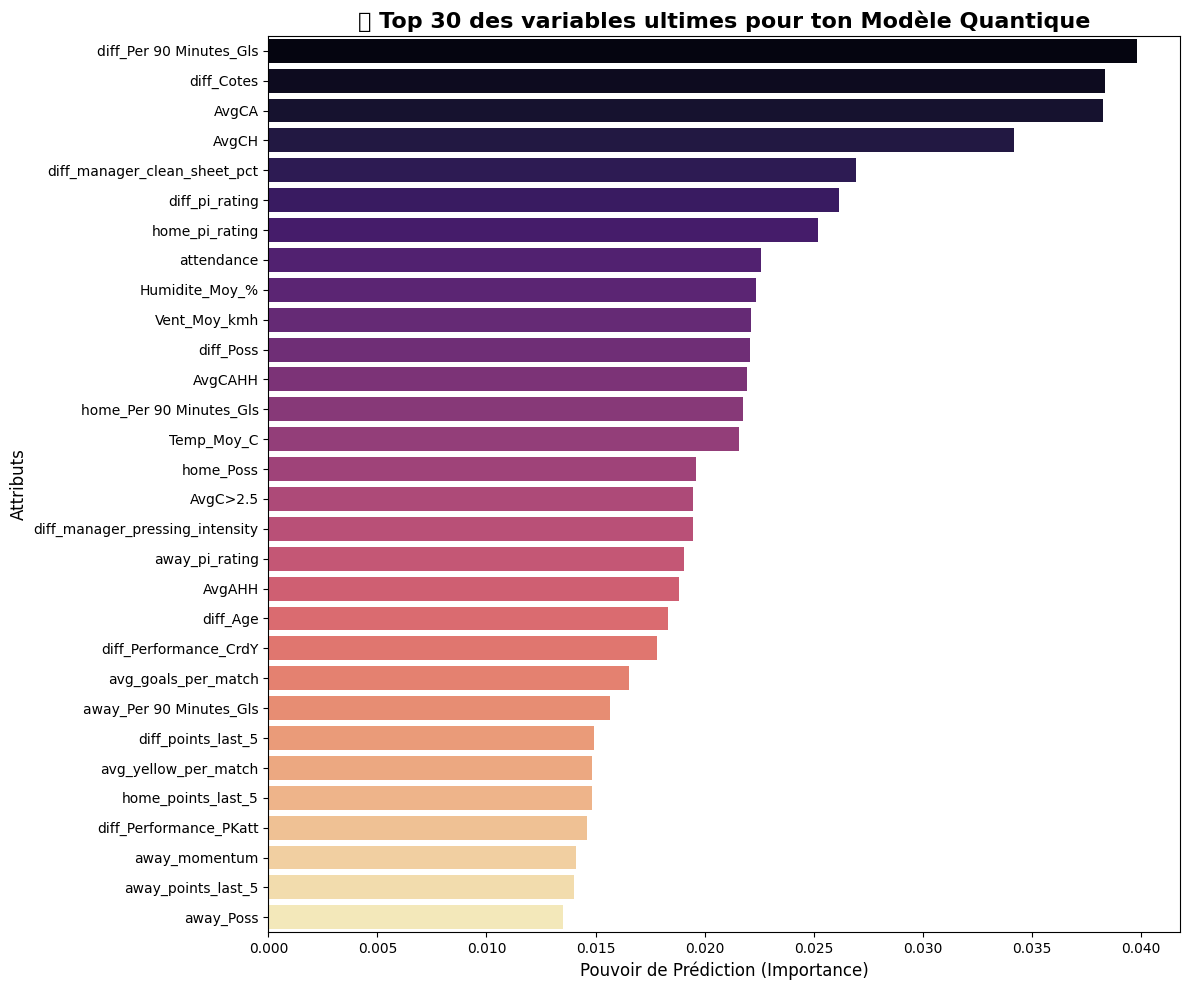

In [242]:
# 2. Entraîner l'Arbre de Décision Magique
print("🌲 Entraînement du Random Forest en cours pour évaluer tes 74 attributs...")
rf_model = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1, max_depth=10)
rf_model.fit(X, y)

# 3. Récupérer les scores d'importance
importances = rf_model.feature_importances_
df_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': importances
})

# Trier du plus important au moins important
df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 4. Afficher le Top 20 en graphique
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Variable', data=df_importance.head(30), palette='magma')
plt.title("🔥 Top 30 des variables ultimes pour ton Modèle Quantique", fontsize=16, fontweight='bold')
plt.xlabel("Pouvoir de Prédiction (Importance)", fontsize=12)
plt.ylabel("Attributs", fontsize=12)
plt.tight_layout()
plt.show()

In [250]:
# On définit le seuil
seuil = 0.02

# On récupère la liste des variables qui dépassent ce seuil
features_selectionnees = df_importance[df_importance['Importance'] > seuil]['Variable'].tolist()

# On crée le nouveau X filtré
X_filtre = data_engineered[features_selectionnees]

print(f"Nombre de variables conservées : {len(features_selectionnees)}")

Nombre de variables conservées : 14


In [251]:
X_filtre.to_csv("data/final_pari.csv")

In [252]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 3. Fonction pour entraîner et tester
def evaluate_rf(X_data, y_data, title):
    # Split 80% train / 20% test
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
    
    # Initialisation du Random Forest
    rf = RandomForestClassifier(n_estimators=400, max_depth=30, random_state=42)
    rf.fit(X_train, y_train)
    
    # Prédiction et score
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"--- RÉSULTATS : {title} ---")
    print(f"Précision (Accuracy) : {acc:.2%}")
    print(classification_report(y_test, y_pred, target_names=['Away Win (0)', 'Draw (1)', 'Home Win (2)']))
    print("-" * 30)
    return rf

model_complet = evaluate_rf(X_filtre, y, "MODÈLE AVEC COTES")

--- RÉSULTATS : MODÈLE AVEC COTES ---
Précision (Accuracy) : 45.83%
              precision    recall  f1-score   support

Away Win (0)       0.46      0.56      0.51        43
    Draw (1)       0.21      0.08      0.11        39
Home Win (2)       0.50      0.63      0.56        62

    accuracy                           0.46       144
   macro avg       0.39      0.42      0.39       144
weighted avg       0.41      0.46      0.42       144

------------------------------


In [253]:
X_train, X_test, y_train, y_test = train_test_split(X_filtre, y, test_size=0.2, random_state=42)

# 3. Entraînement avec gestion du déséquilibre (class_weight)
# Le 'balanced' va forcer le modèle à ne plus ignorer les matchs nuls
rf_final = RandomForestClassifier(
    n_estimators=500, 
    max_depth=20,
    class_weight='balanced', 
    random_state=42
)
rf_final.fit(X_train, y_train)

# 4. ANALYSE DE LA CONFIANCE (Le secret pour les 70%)
# On récupère les probabilités au lieu des classes directes
probs = rf_final.predict_proba(X_test)
max_probs = np.max(probs, axis=1) # Probabilité de la classe choisie
preds = rf_final.predict(X_test)

# Création d'un tableau de résultats
results = pd.DataFrame({
    'Actual': y_test,
    'Prediction': preds,
    'Confidence': max_probs
})

# Calcul de l'accuracy globale
acc_globale = accuracy_score(y_test, preds)

# Calcul de l'accuracy sur les matchs "Haute Confiance" (> 65% de certitude)
seuil = 0.70
high_conf = results[results['Confidence'] >= seuil]
acc_high = accuracy_score(high_conf['Actual'], high_conf['Prediction']) if len(high_conf) > 0 else 0

print(f"Accuracy Globale : {acc_globale:.2%}")
print(f"Accuracy Haute Confiance (Seuil {seuil:.0%}) : {acc_high:.2%}")
print(f"Nombre de matchs jugés 'surs' : {len(high_conf)} sur {len(X_test)}")

Accuracy Globale : 46.53%
Accuracy Haute Confiance (Seuil 70%) : 65.22%
Nombre de matchs jugés 'surs' : 23 sur 144


In [254]:
import xgboost as xgb

In [257]:
X_temp, X_test, y_temp, y_test = train_test_split(X_filtre, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 2. Configuration du modèle XGBoost
model_xgb = xgb.XGBClassifier(
    n_estimators=150,        # Moins d'arbres
    learning_rate=0.05,
    max_depth=3,             # Arbres très peu profonds (très important !)
    min_child_weight=5,      # Il faut au moins 5 matchs similaires pour créer une règle
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds = 20,
    reg_lambda=5,            # Pénalité L2 (empêche l'overconfidence)
    reg_alpha=1,             # Pénalité L1 (ignore les variables inutiles)
    objective='multi:softprob',
    num_class=3,
    random_state=42
)

# 3. Entraînement avec Early Stopping
# Il s'arrêtera si le mlogloss sur X_val ne baisse plus pendant 50 rounds
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False # Pour ne pas inonder l'écran de logs
)

# 4. Evaluation
preds = model_xgb.predict(X_test)
probs = model_xgb.predict_proba(X_test)
max_probs = np.max(probs, axis=1)

print(f"Meilleure itération : {model_xgb.best_iteration}")
print(f"Accuracy sur le Test Set : {accuracy_score(y_test, preds):.2%}")

# Filtre de confiance pour viser les 70%
seuil = 0.65
results = pd.DataFrame({'Actual': y_test, 'Pred': preds, 'Conf': max_probs})
high_conf = results[results['Conf'] >= seuil]

if len(high_conf) > 0:
    print(f"Accuracy Haute Confiance (>{seuil}) : {accuracy_score(high_conf['Actual'], high_conf['Pred']):.2%}")
    print(f"Nombre de matchs : {len(high_conf)}/{len(X_test)}")

Meilleure itération : 28
Accuracy sur le Test Set : 51.85%
Accuracy Haute Confiance (>0.65) : 52.00%
Nombre de matchs : 25/216
